 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
 2. постройте гистограмму
 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
Для каждого решения - напечатайте результат

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Загрузка

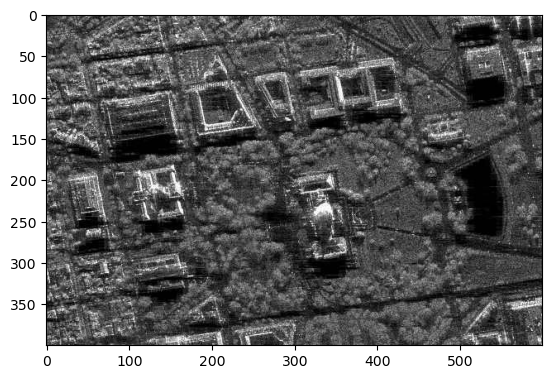

In [2]:
image = cv2.imread('sar_1_gray.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image)

# 1. Гистограммы

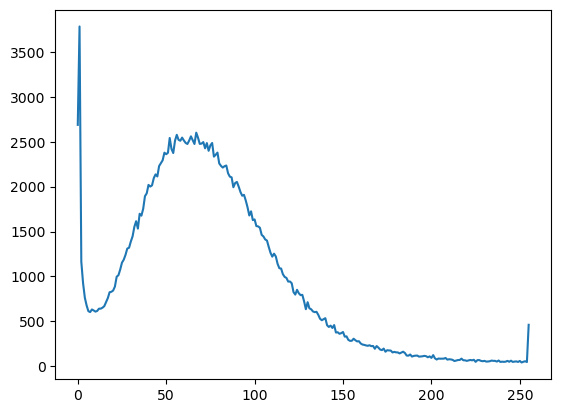

In [3]:
histSize = 256
histRange = (0, 256)
accumulate = False
b = image[:,:,0]

b_hist = cv2.calcHist([b], [0], None, [histSize], histRange, accumulate=accumulate)
plt.plot(b_hist)

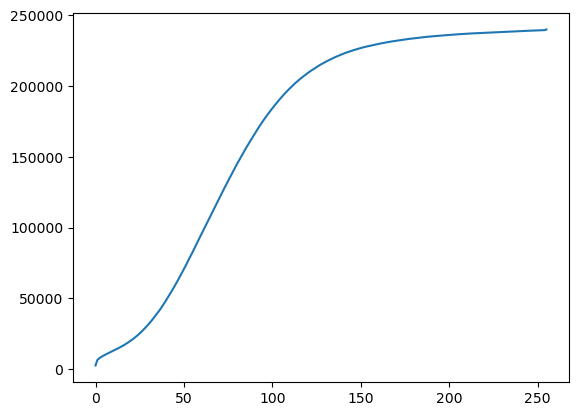

In [4]:
b_hist_cum = b_hist.cumsum()
plt.plot(b_hist_cum)

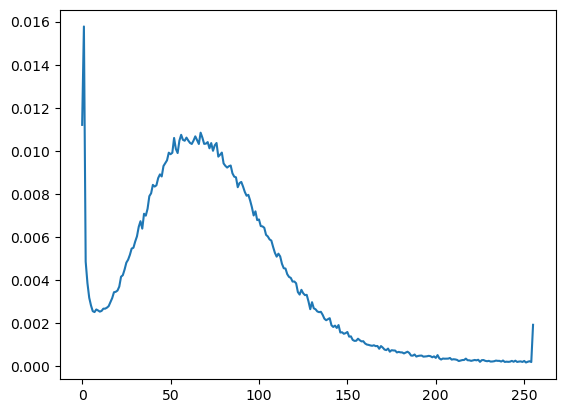

In [5]:
b_hist_norm = b_hist /  (image.shape[0] * image.shape[1])
plt.plot(b_hist_norm)

# 3. Гамма-коррекция

In [7]:
def gamma_correction(image, gamma):
    """
    Гамма-коррекция изображения.
    gamma < 1: осветление
    gamma > 1: затемнение
    """
    normalized = image.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma)
    corrected_image = (corrected * 255).astype(np.uint8)
    return corrected_image

gamma_05 = gamma_correction(image, 0.5) 
gamma_15 = gamma_correction(image, 1.5) 

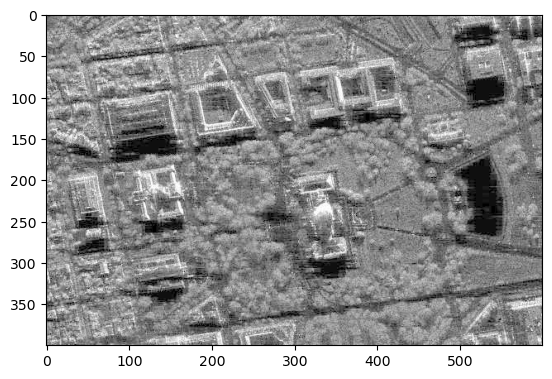

In [9]:
plt.imshow(gamma_05)

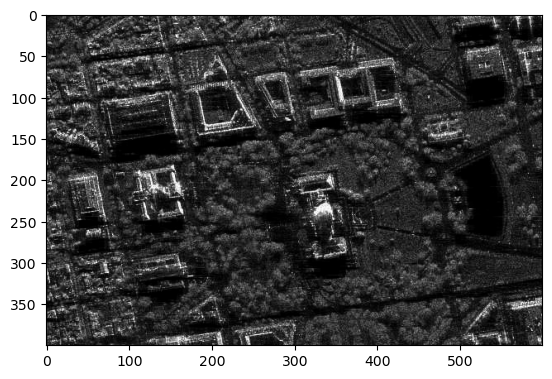

In [10]:
plt.imshow(gamma_15)

In [11]:
from skimage.metrics import structural_similarity, mean_squared_error


# 4. Сравнение

In [12]:
g_05 = cv2.cvtColor(gamma_05, cv2.COLOR_BGR2GRAY) 
(ssim, diff) = structural_similarity(image_gray, g_05, full=True)
diff = (diff * 255).astype("uint8")
print(f"SSIM: {ssim}")
mse = mean_squared_error(image_gray, g_05)
print(f"MSE: {mse}")

SSIM: 0.7875008686792753
MSE: 3250.429145833333


In [13]:
g_15 = cv2.cvtColor(gamma_15, cv2.COLOR_BGR2GRAY) 
(ssim, diff) = structural_similarity(image_gray, g_15, full=True)
diff = (diff * 255).astype("uint8")
print(f"SSIM: {ssim}")
mse = mean_squared_error(image_gray, g_15)
print(f"MSE: {mse}")

SSIM: 0.8065788107754002
MSE: 971.8206541666667


In [14]:
mean = image_gray.mean()
std = image_gray.std()
eq_gray = cv2.equalizeHist(image_gray)
print(mean,std)

74.94157083333333 43.658465466227916


# 5. Статистическая цвето-коррекция

In [15]:
def statistical_color_correction(original_img, reference_stats):
    """
    Статистическая цветокоррекция на основе статистики reference изображения.
    """
    orig_mean = original_img.mean()
    orig_std = original_img.std()
    
    ref_mean = reference_stats['mean']
    ref_std = reference_stats['std']
    
    corrected_img = ((original_img.astype(np.float32) - orig_mean) * (ref_std / max(orig_std, 1e-6)) + ref_mean)
    corrected_img = np.clip(corrected_img, 0, 255).astype(np.uint8)
    
    return corrected_img

Исходная статистика: mean=74.94, std=43.66
Нормализованная: mean=127.03, std=74.27


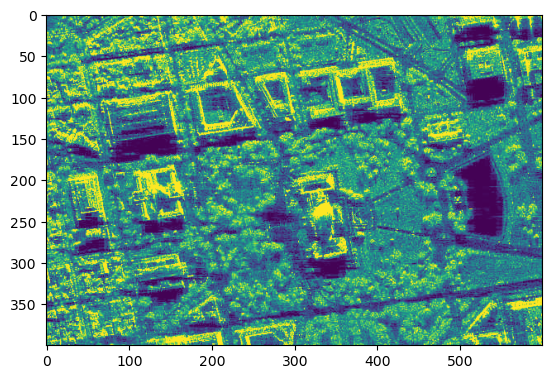

In [16]:
eq_mean = eq_gray.mean()
eq_std = eq_gray.std()

print(f"Исходная статистика: mean={mean:.2f}, std={std:.2f}")
print(f"Нормализованная: mean={eq_mean:.2f}, std={eq_std:.2f}")

reference_stats = {'mean': eq_mean, 'std': eq_std}

corrected_image = statistical_color_correction(image_gray, reference_stats)
plt.imshow(corrected_image)

# 6. Разные пороги

t=50 - белых пикселей: 169178
t=100 - белых пикселей: 55653
t=150 - белых пикселей: 13083
t=200 - белых пикселей: 3830


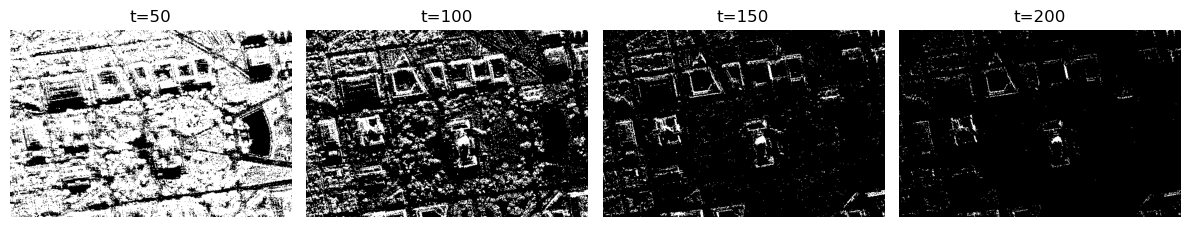

In [21]:
thresholds = [50, 100, 150, 200]
plt.figure(figsize=(12, 4))

for i, t in enumerate(thresholds):
    _, thresh = cv2.threshold(image_gray, t, 255, cv2.THRESH_BINARY)
    print(f"t={t} - белых пикселей: {(thresh==255).sum()}")
    plt.subplot(1, len(thresholds), i+1)
    plt.imshow(thresh, cmap='gray')
    plt.title(f"t={t}")
    plt.axis('off')

plt.tight_layout()
plt.show()